# 04. Media Deep Dive

This notebook interprets the fitted MMM through:

1. posterior media parameters;
2. saturation response curves;
3. channel contributions;
4. historical ROAS;
5. marginal ROAS from a 1% spend increase.

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from pymc_marketing.mmm.multidimensional import MMM


root = Path("..")

mmm = MMM.load(
    root / "artifacts/mmm_regularized_with_ppc.nc"
)

df = pd.read_csv(
    root / "data/scenario_a/scenario_a_train.csv",
    parse_dates=["date_week"],
)

post = mmm.idata.posterior
channels = post.channel.values.tolist()

names = {
    c: c.removesuffix("_spend").replace("_", " ").title()
    for c in channels
}

y_scale = df["revenue"].abs().max()
x_scale = df[channels].abs().max()

# Original revenue scale
contribution = post["channel_contribution"] * y_scale

print(channels)

['tv_spend', 'google_search_spend', 'tiktok_spend']


## Posterior Media Parameters

- `adstock_alpha` controls carryover persistence.
- `saturation_lam` controls how quickly diminishing returns occur.
- `saturation_beta` controls the maximum contribution scale.

A larger alpha means slower decay and stronger carryover.

In [12]:
parameter_summary = pd.DataFrame(
    {
        "alpha": post["adstock_alpha"]
        .median(("chain", "draw"))
        .values,

        "lambda": post["saturation_lam"]
        .median(("chain", "draw"))
        .values,

        "beta_revenue_scale": (
            post["saturation_beta"] * y_scale
        )
        .median(("chain", "draw"))
        .values,
    },
    index=[names[c] for c in channels],
)

parameter_summary.round(3)

,alpha,lambda,beta_revenue_scale
Tv,0.364,2.586,112.934
Google Search,0.212,2.881,97.929
Tiktok,0.151,2.432,71.066


## Saturation Response Curves

The logistic saturation function represents diminishing returns.

The solid line is the posterior median, and the shaded region is the central 94% credible interval.

The vertical dotted line is the maximum spend observed in training. Values beyond it are extrapolations.

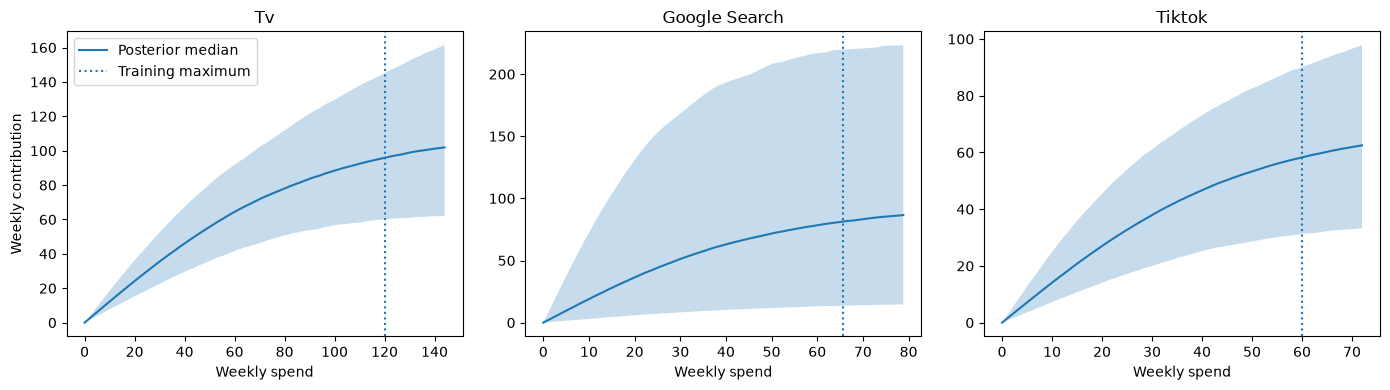

In [13]:
sample = post.stack(
    sample=("chain", "draw")
)

fig, axes = plt.subplots(
    1,
    len(channels),
    figsize=(14, 4),
)

for ax, channel in zip(axes, channels):
    spend = np.linspace(
        0,
        1.2 * df[channel].max(),
        120,
    )

    lam = sample["saturation_lam"].sel(
        channel=channel
    ).values[:, None]

    beta = sample["saturation_beta"].sel(
        channel=channel
    ).values[:, None] * y_scale

    curves = beta * np.tanh(
        lam * spend[None, :]
        / x_scale[channel]
        / 2
    )

    low, median, high = np.quantile(
        curves,
        [0.03, 0.50, 0.97],
        axis=0,
    )

    ax.fill_between(
        spend,
        low,
        high,
        alpha=0.25,
    )

    ax.plot(
        spend,
        median,
        label="Posterior median",
    )

    ax.axvline(
        df[channel].max(),
        linestyle=":",
        label="Training maximum",
    )

    ax.set(
        title=names[channel],
        xlabel="Weekly spend",
    )

axes[0].set_ylabel(
    "Weekly contribution"
)
axes[0].legend()

plt.tight_layout()
plt.show()

## Channel Contributions

The posterior channel contributions show how much revenue the model attributes to each channel over time.

The area chart uses the posterior median contribution for each week.

The table reports total contribution over the training period with a 94% credible interval.

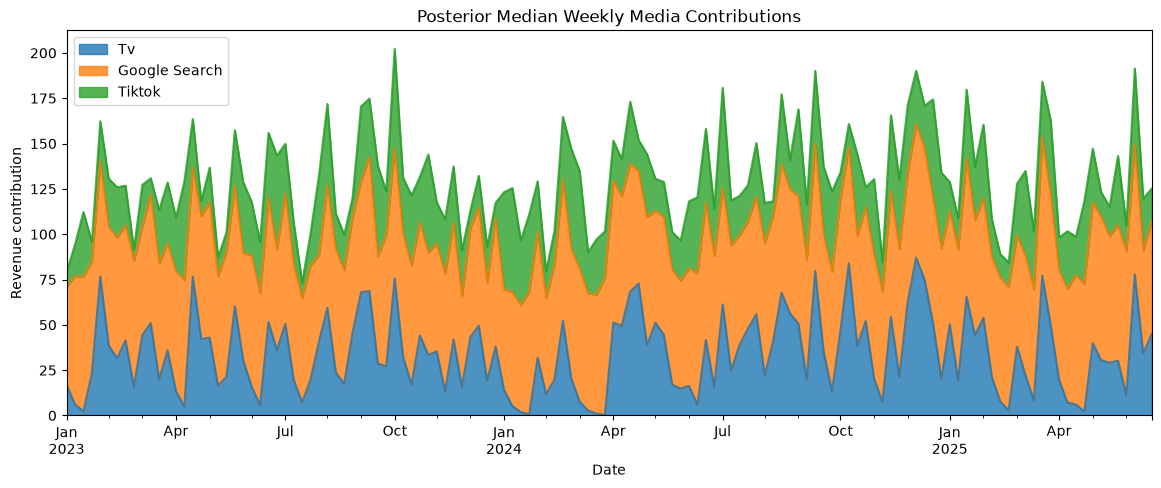

,3%,Median,97%
Tv,2809.1,4454.5,6609.9
Google Search,1412.7,8637.9,25633.9
Tiktok,1976.6,3744.8,6199.2


In [14]:
median = contribution.median(
    ("chain", "draw")
).to_pandas()

median.columns = [
    names[c] for c in channels
]

median.plot.area(
    figsize=(14, 5),
    alpha=0.8,
)

plt.title(
    "Posterior Median Weekly Media Contributions"
)
plt.ylabel(
    "Revenue contribution"
)
plt.xlabel(
    "Date"
)
plt.show()


total = contribution.sum("date")

total_summary = (
    total.quantile(
        [0.03, 0.50, 0.97],
        ("chain", "draw"),
    )
    .transpose("channel", "quantile")
    .to_pandas()
)

total_summary.index = [
    names[c] for c in total_summary.index
]

total_summary.columns = [
    "3%",
    "Median",
    "97%",
]

total_summary.round(1)

,Spend Share,Contribution Share 3%,Contribution Share Median,Contribution Share 97%
Tiktok,23.3,8.9,21.9,43.5
Tv,31.3,11.3,26.3,49.3
Google Search,45.3,14.0,51.3,77.7


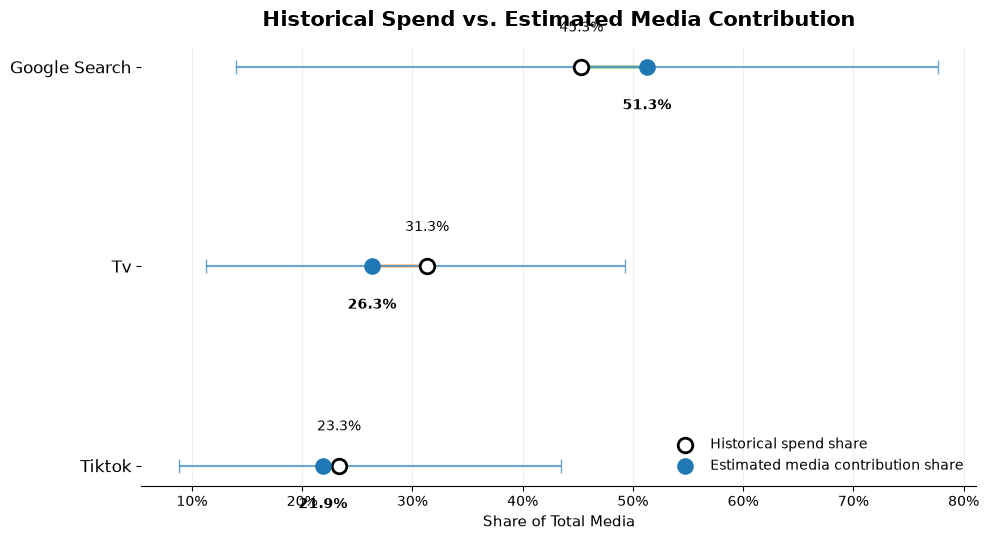

In [15]:
# ============================================================
# Historical Spend Share vs Estimated Media Contribution Share
# ============================================================

# 1. Historical spend share
historical_spend = df[channels].sum()
spend_share = historical_spend / historical_spend.sum()


# 2. Posterior contribution share
# total has dimensions: chain x draw x channel
total = contribution.sum("date")

# IMPORTANT:
# Compute the share within EACH posterior draw first,
# then summarize across posterior draws.
contribution_share = total / total.sum("channel")


# 3. Posterior summary: median + 94% credible interval
share_summary = (
    contribution_share.quantile(
        [0.03, 0.50, 0.97],
        dim=("chain", "draw"),
    )
    .transpose("channel", "quantile")
    .to_pandas()
)

share_summary.columns = [
    "Contribution Share 3%",
    "Contribution Share Median",
    "Contribution Share 97%",
]


# 4. Combine spend share and contribution share
plot_df = pd.DataFrame(
    {
        "Spend Share": spend_share,
        "Contribution Share 3%":
            share_summary["Contribution Share 3%"],
        "Contribution Share Median":
            share_summary["Contribution Share Median"],
        "Contribution Share 97%":
            share_summary["Contribution Share 97%"],
    }
)

plot_df.index = [
    names[c] for c in plot_df.index
]

# Sort by estimated contribution share
plot_df = plot_df.sort_values(
    "Contribution Share Median",
    ascending=True,
)

display(
    (plot_df * 100).round(1)
)


# ============================================================
# 5. Presentation-friendly dumbbell chart
# ============================================================

fig, ax = plt.subplots(figsize=(10, 5.5))

y = np.arange(len(plot_df))

spend = plot_df["Spend Share"].values * 100
contrib = plot_df["Contribution Share Median"].values * 100
lower = plot_df["Contribution Share 3%"].values * 100
upper = plot_df["Contribution Share 97%"].values * 100


# Connecting line: historical allocation -> estimated contribution
for i in range(len(plot_df)):
    ax.plot(
        [spend[i], contrib[i]],
        [y[i], y[i]],
        linewidth=3,
        alpha=0.35,
    )


# Historical spend share
ax.scatter(
    spend,
    y,
    s=110,
    marker="o",
    facecolors="white",
    edgecolors="black",
    linewidth=2,
    label="Historical spend share",
    zorder=3,
)


# Estimated contribution share
ax.scatter(
    contrib,
    y,
    s=120,
    marker="o",
    label="Estimated media contribution share",
    zorder=4,
)


# 94% credible interval for contribution share
ax.errorbar(
    contrib,
    y,
    xerr=[
        contrib - lower,
        upper - contrib,
    ],
    fmt="none",
    capsize=5,
    linewidth=1.5,
    alpha=0.65,
    zorder=2,
)


# Labels
for i in range(len(plot_df)):
    ax.text(
        spend[i],
        y[i] + 0.16,
        f"{spend[i]:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

    ax.text(
        contrib[i],
        y[i] - 0.16,
        f"{contrib[i]:.1f}%",
        ha="center",
        va="top",
        fontsize=10,
        fontweight="bold",
    )


ax.set_yticks(y)
ax.set_yticklabels(plot_df.index, fontsize=12)

ax.set_xlabel("Share of Total Media", fontsize=11)

ax.set_title(
    "Historical Spend vs. Estimated Media Contribution",
    fontsize=15,
    fontweight="bold",
    pad=15,
)

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0f}%")
)

ax.grid(
    axis="x",
    alpha=0.2,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    frameon=False,
    loc="lower right",
)

plt.tight_layout()
plt.show()

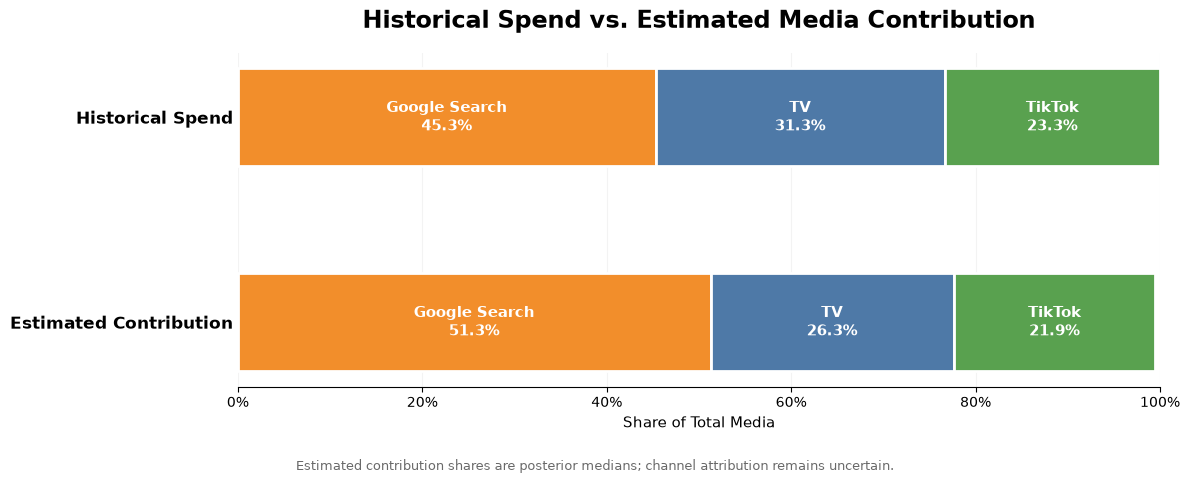

In [16]:
# ============================================================
# Presentation chart:
# Historical Spend Mix vs Estimated Media Contribution Mix
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# These must match plot_df.index exactly
order = ["Google Search", "Tv", "Tiktok"]

# Pretty labels only for display
display_names = {
    "Google Search": "Google Search",
    "Tv": "TV",
    "Tiktok": "TikTok",
}

# Convert shares to percentages
spend = plot_df.loc[order, "Spend Share"] * 100
contribution = plot_df.loc[order, "Contribution Share Median"] * 100


fig, ax = plt.subplots(figsize=(12, 4.8))

y_positions = [1, 0]
bar_height = 0.48

colors = {
    "Google Search": "#F28E2B",
    "Tv": "#4E79A7",
    "Tiktok": "#59A14F",
}


# -----------------------------
# Historical Spend
# -----------------------------
left = 0

for channel in order:
    value = spend[channel]

    ax.barh(
        y_positions[0],
        value,
        left=left,
        height=bar_height,
        color=colors[channel],
        edgecolor="white",
        linewidth=2,
    )

    ax.text(
        left + value / 2,
        y_positions[0],
        f"{display_names[channel]}\n{value:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )

    left += value


# -----------------------------
# Estimated Contribution
# -----------------------------
left = 0

for channel in order:
    value = contribution[channel]

    ax.barh(
        y_positions[1],
        value,
        left=left,
        height=bar_height,
        color=colors[channel],
        edgecolor="white",
        linewidth=2,
    )

    ax.text(
        left + value / 2,
        y_positions[1],
        f"{display_names[channel]}\n{value:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white",
    )

    left += value


# -----------------------------
# Formatting
# -----------------------------
ax.set_xlim(0, 100)

ax.set_yticks(y_positions)
ax.set_yticklabels(
    ["Historical Spend", "Estimated Contribution"],
    fontsize=12,
    fontweight="bold",
)

ax.set_title(
    "Historical Spend vs. Estimated Media Contribution",
    fontsize=17,
    fontweight="bold",
    pad=18,
)

ax.set_xticks(np.arange(0, 101, 20))
ax.set_xticklabels(
    [f"{x}%" for x in np.arange(0, 101, 20)]
)

ax.set_xlabel("Share of Total Media", fontsize=11)

ax.grid(axis="x", alpha=0.15)
ax.set_axisbelow(True)

for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)

ax.tick_params(axis="y", length=0)

fig.text(
    0.5,
    0.01,
    "Estimated contribution shares are posterior medians; channel attribution remains uncertain.",
    ha="center",
    fontsize=9,
    color="dimgray",
)

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## ROAS and Marginal ROAS

Historical ROAS is:


$$
\mathrm{ROAS}_m
=
\frac{\text{Total channel contribution}}
{\text{Total channel spend}}.
$$

Marginal ROAS is estimated by increasing every weekly spend value for one channel by 1%:

$$
\mathrm{mROAS}_m
\approx
\frac{
\text{Contribution at 101% spend}
-
\text{Contribution at current spend}
}{
0.01 \times \text{Total spend}
}.
$$

ROAS measures the average historical return. mROAS estimates the return from an additional dollar near the current spending level.

This simplified calculation only includes contribution within the training window and therefore excludes carryover after the final week.

In [17]:
spend = xr.DataArray(
    df[channels].sum().to_numpy(),
    dims="channel",
    coords={"channel": channels},
)

roas = total / spend


# Current saturation output:
# contribution / beta = tanh(lambda * adstock / 2)
saturation = (
    post["channel_contribution"]
    / post["saturation_beta"]
).clip(
    min=0,
    max=0.999999,
)

# A 1% spend increase also increases adstock by 1%
contribution_plus = (
    post["saturation_beta"]
    * np.tanh(
        1.01 * np.arctanh(saturation)
    )
    * y_scale
)

mroas = (
    contribution_plus - contribution
).sum("date") / (
    0.01 * spend
)


def summarize(x):
    table = (
        x.quantile(
            [0.03, 0.50, 0.97],
            ("chain", "draw"),
        )
        .transpose("channel", "quantile")
        .to_pandas()
    )

    table.index = [
        names[c] for c in table.index
    ]

    table.columns = [
        "3%",
        "Median",
        "97%",
    ]

    return table


pd.concat(
    {
        "ROAS": summarize(roas),
        "mROAS (+1%)": summarize(mroas),
    },
    axis=1,
).round(3)

ValueError: operands could not be broadcast together with shapes (4,1000,3,130) (3,) 

Google Search has the highest median historical ROAS, but also the greatest uncertainty. Its marginal ROAS is the lowest, suggesting that although the channel performed well on average, additional spend may face stronger diminishing returns. TikTok has the highest median marginal ROAS, but the credible intervals overlap substantially, so I would treat the channel ranking as uncertain and use posterior-based constrained budget optimization rather than relying only on point estimates.